# 🇮🇳 India Population Prediction using Polynomial Regression

This notebook builds a **Polynomial Regression** model to predict India's:
- **Total Population**
- **Male Population**
- **Female Population**

**Data Source:** UN World Population Prospects (1950–2025)

---

## 1. Import Libraries

In [49]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Machine Learning
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Load and Explore the Dataset

In [50]:
# Load the dataset
df = pd.read_csv('india_population_1950_2025.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Years Covered: {df["Year"].min()} to {df["Year"].max()}')
print(f'\n--- Data Types ---')
print(df.dtypes)
print(f'\n--- Missing Values ---')
print(df.isnull().sum())
print(f'\n--- First 5 Rows ---')
df.head()

Dataset Shape: (76, 4)
Years Covered: 1950 to 2025

--- Data Types ---
Year                 int64
Total Population     int64
Male Population      int64
Female Population    int64
dtype: object

--- Missing Values ---
Year                 0
Total Population     0
Male Population      0
Female Population    0
dtype: int64

--- First 5 Rows ---


,Year,Total Population,Male Population,Female Population
0,1950,346278821,177866756,168412066
1,1951,353870057,181867518,172002538
2,1952,361874903,186091020,175783883
3,1953,370104574,190411808,179692766
4,1954,378687138,194907910,183779228


In [51]:
# Generate future years
future_years = np.arange(2026, 2051)
future_X = (future_years - 1950).reshape(-1, 1)

# Predict Total and Male
future_total = model_total.predict(future_X)
future_male = model_male.predict(future_X)

# Derive Female as Total - Male (guarantees consistency!)
future_female = future_total - future_male

# Create predictions DataFrame
predictions_df = pd.DataFrame({
    'Year': future_years,
    'Predicted Total Population': future_total.astype(int),
    'Predicted Male Population': future_male.astype(int),
    'Predicted Female Population': future_female.astype(int)
})

# Verify consistency
predictions_df['Male + Female'] = predictions_df['Predicted Male Population'] + predictions_df['Predicted Female Population']
predictions_df['Consistent'] = predictions_df['Male + Female'] == predictions_df['Predicted Total Population']

print('📊 Future Population Predictions (2026-2050)')
print(f'✅ All predictions consistent (Male + Female = Total): {predictions_df["Consistent"].all()}\n')
predictions_df[['Year', 'Predicted Total Population', 'Predicted Male Population', 'Predicted Female Population']]

📊 Future Population Predictions (2026-2050)
✅ All predictions consistent (Male + Female = Total): False



,Year,Predicted Total Population,Predicted Male Population,Predicted Female Population
0,2026,1498261133,799735259,698525874
1,2027,1513751500,809635701,704115798
2,2028,1528762245,819393187,709369058
3,2029,1543257915,828993528,714264387
4,2030,1557201988,838422091,718779896
5,2031,1570556857,847663787,722893070
6,2032,1583283821,856703067,726580754
7,2033,1595343067,865523915,729819152
8,2034,1606693659,874109845,732583813
9,2035,1617293517,882443892,734849625


In [52]:
# Last 5 rows
print('--- Last 5 Rows ---')
df.tail()

--- Last 5 Rows ---


,Year,Total Population,Male Population,Female Population
71,2021,1383112050,725622480,657489570
72,2022,1425423212,735977539,689445673
73,2023,1438069596,742310851,695758745
74,2024,1441719852,744167425,697552427
75,2025,1454606724,750434970,704171754


## 3. Exploratory Data Analysis (EDA)

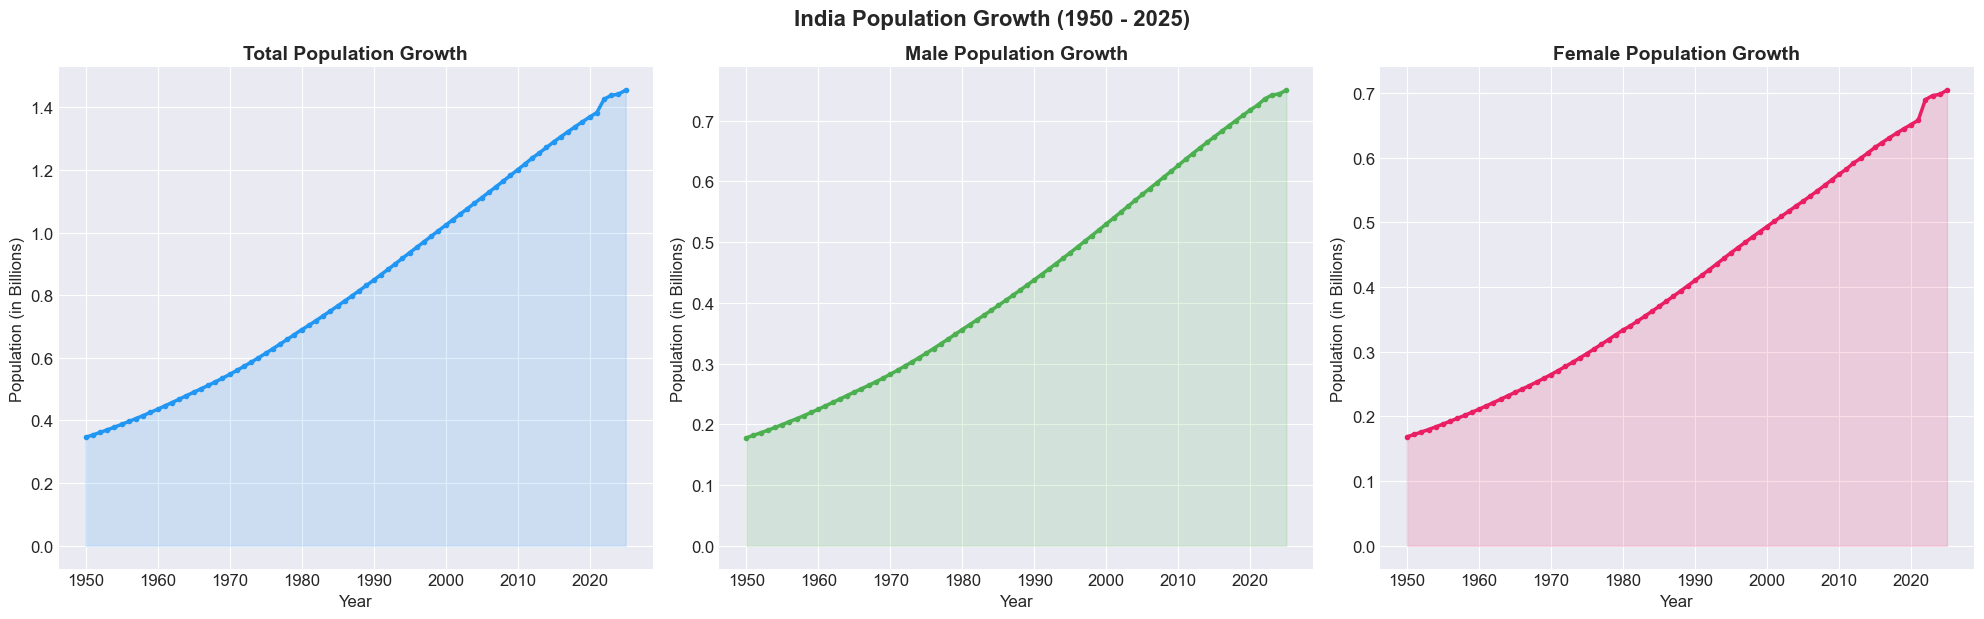

In [53]:
# Plot 1: Population Growth Over Time
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Total Population
axes[0].plot(df['Year'], df['Total Population'] / 1e9, color='#2196F3', linewidth=2.5, marker='o', markersize=3)
axes[0].set_title('Total Population Growth', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Population (in Billions)')
axes[0].fill_between(df['Year'], df['Total Population'] / 1e9, alpha=0.15, color='#2196F3')

# Male Population
axes[1].plot(df['Year'], df['Male Population'] / 1e9, color='#4CAF50', linewidth=2.5, marker='o', markersize=3)
axes[1].set_title('Male Population Growth', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Population (in Billions)')
axes[1].fill_between(df['Year'], df['Male Population'] / 1e9, alpha=0.15, color='#4CAF50')

# Female Population
axes[2].plot(df['Year'], df['Female Population'] / 1e9, color='#E91E63', linewidth=2.5, marker='o', markersize=3)
axes[2].set_title('Female Population Growth', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Population (in Billions)')
axes[2].fill_between(df['Year'], df['Female Population'] / 1e9, alpha=0.15, color='#E91E63')

plt.tight_layout()
plt.suptitle('India Population Growth (1950 - 2025)', fontsize=16, fontweight='bold', y=1.03)
plt.show()

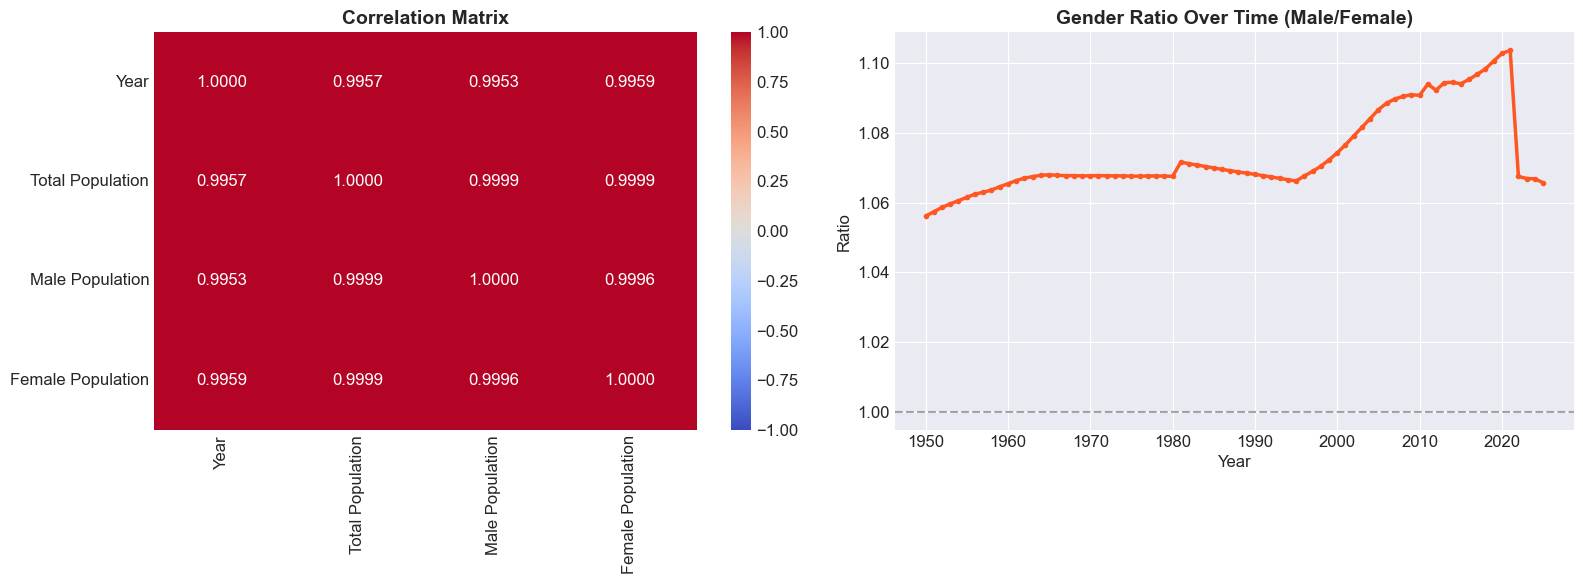

In [54]:
# Plot 2: Correlation Heatmap & Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation Heatmap
corr = df[['Year', 'Total Population', 'Male Population', 'Female Population']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.4f', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# Gender Ratio Over Time
df['Gender Ratio'] = df['Male Population'] / df['Female Population']
axes[1].plot(df['Year'], df['Gender Ratio'], color='#FF5722', linewidth=2.5, marker='o', markersize=3)
axes[1].set_title('Gender Ratio Over Time (Male/Female)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Ratio')
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 4. Prepare Data for Polynomial Regression

In [55]:
# Use Year as the single feature (PolynomialFeatures will generate polynomial terms)
# We normalize Year to avoid numerical instability with large powers
df_model = df[['Year', 'Total Population', 'Male Population', 'Female Population']].copy()

# Feature: Years since 1950 (avoids huge numbers when taking powers)
df_model['Years_Since_1950'] = df_model['Year'] - 1950

# Use Years_Since_1950 as the single input feature
X = df_model[['Years_Since_1950']].values
y_total = df_model['Total Population'].values
y_male = df_model['Male Population'].values
y_female = df_model['Female Population'].values

print(f'Feature Matrix Shape: {X.shape}')
print(f'Target (Total) Shape: {y_total.shape}')
print(f'Target (Male) Shape:  {y_male.shape}')
print(f'Target (Female) Shape: {y_female.shape}')
print(f'\nFeature range: {X.min()} to {X.max()}')

Feature Matrix Shape: (76, 1)
Target (Total) Shape: (76,)
Target (Male) Shape:  (76,)
Target (Female) Shape: (76,)

Feature range: 0 to 75


In [56]:
# Time-Series Split: Use last 20% as test set (preserving temporal order)
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train_total, y_test_total = y_total[:split_idx], y_total[split_idx:]
y_train_male, y_test_male = y_male[:split_idx], y_male[split_idx:]
y_train_female, y_test_female = y_female[:split_idx], y_female[split_idx:]

print(f'Training Set Size: {X_train.shape[0]} samples (Years {1950} - {1950 + X_train[-1][0]:.0f})')
print(f'Testing Set Size:  {X_test.shape[0]} samples (Years {1950 + X_test[0][0]:.0f} - {1950 + X_test[-1][0]:.0f})')

Training Set Size: 60 samples (Years 1950 - 2009)
Testing Set Size:  16 samples (Years 2010 - 2025)


## 5. Find Optimal Polynomial Degree

In [57]:
# Test different polynomial degrees using TimeSeriesSplit cross-validation
print('🔍 Finding optimal polynomial degree using TimeSeriesSplit CV...\n')

tscv = TimeSeriesSplit(n_splits=5)
best_degree = 1
best_score = -np.inf
results = []

for degree in range(1, 7):
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train_total, cv=tscv, scoring='r2')
    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    
    results.append({
        'Degree': degree,
        'Mean CV R²': mean_score,
        'Std CV R²': std_score,
        'Fold Scores': cv_scores
    })
    
    print(f'  Degree {degree}: Mean R² = {mean_score:.6f} (± {std_score:.6f})')
    print(f'    Fold Scores: {[f"{s:.6f}" for s in cv_scores]}')
    
    if mean_score > best_score:
        best_score = mean_score
        best_degree = degree

print(f'\n✅ Best Polynomial Degree: {best_degree} (Mean CV R² = {best_score:.6f})')

🔍 Finding optimal polynomial degree using TimeSeriesSplit CV...

  Degree 1: Mean R² = -0.218760 (± 0.573036)
    Fold Scores: ['0.525585', '0.307414', '-0.257545', '-0.675169', '-0.994087']
  Degree 2: Mean R² = 0.837449 (± 0.200107)
    Fold Scores: ['0.448963', '0.944444', '0.978819', '0.970922', '0.844099']
  Degree 3: Mean R² = 0.129134 (± 0.979423)
    Fold Scores: ['-1.813131', '0.683609', '0.712853', '0.693220', '0.369120']
  Degree 4: Mean R² = 0.104286 (± 1.201788)
    Fold Scores: ['-2.287562', '0.858489', '0.720489', '0.738168', '0.491847']
  Degree 5: Mean R² = 0.853939 (± 0.106441)
    Fold Scores: ['0.651074', '0.904770', '0.919275', '0.946701', '0.847875']
  Degree 6: Mean R² = -1.771533 (± 4.606161)
    Fold Scores: ['-10.865946', '-0.920297', '0.980092', '0.956495', '0.991991']

✅ Best Polynomial Degree: 5 (Mean CV R² = 0.853939)


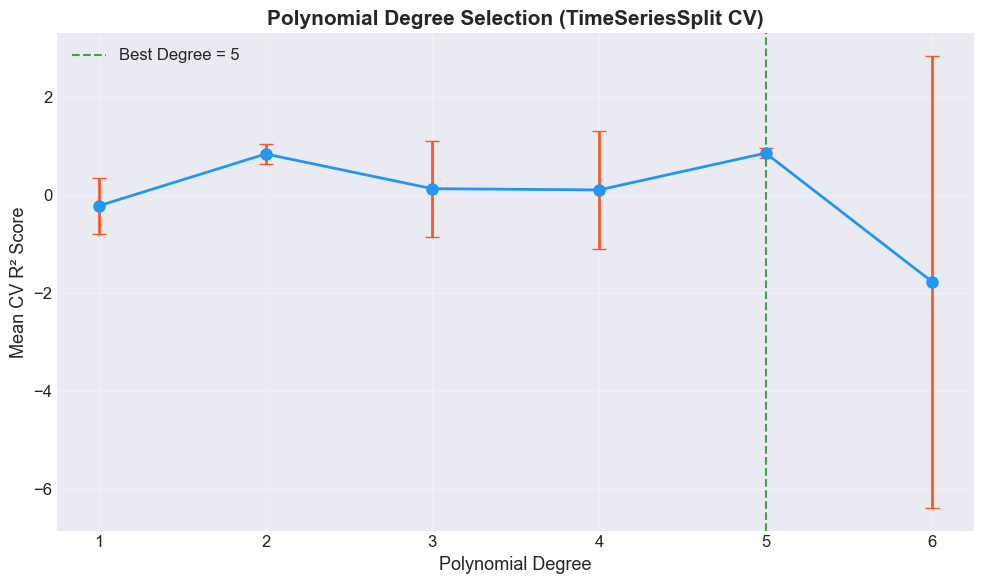

In [58]:
# Visualize CV scores by degree
degrees = [r['Degree'] for r in results]
mean_scores = [r['Mean CV R²'] for r in results]
std_scores = [r['Std CV R²'] for r in results]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(degrees, mean_scores, yerr=std_scores, marker='o', linewidth=2, 
            markersize=8, color='#2196F3', ecolor='#FF5722', capsize=5)
ax.axvline(x=best_degree, color='green', linestyle='--', alpha=0.7, label=f'Best Degree = {best_degree}')
ax.set_xlabel('Polynomial Degree', fontsize=13)
ax.set_ylabel('Mean CV R² Score', fontsize=13)
ax.set_title('Polynomial Degree Selection (TimeSeriesSplit CV)', fontsize=15, fontweight='bold')
ax.set_xticks(degrees)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Fine-Tune Ridge Alpha with Best Degree

In [59]:
# Fine-tune Ridge regularization parameter
print(f'🔍 Tuning Ridge alpha with degree={best_degree} using TimeSeriesSplit CV...\n')

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
best_alpha = 1.0
best_alpha_score = -np.inf

for alpha in alphas:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train_total, cv=tscv, scoring='r2')
    mean_score = cv_scores.mean()
    
    print(f'  Alpha = {alpha:>8}: Mean R² = {mean_score:.6f}')
    
    if mean_score > best_alpha_score:
        best_alpha_score = mean_score
        best_alpha = alpha

print(f'\n✅ Best Alpha: {best_alpha} (Mean CV R² = {best_alpha_score:.6f})')

🔍 Tuning Ridge alpha with degree=5 using TimeSeriesSplit CV...

  Alpha =    0.001: Mean R² = 0.816899
  Alpha =     0.01: Mean R² = 0.828988
  Alpha =      0.1: Mean R² = -0.311124
  Alpha =      1.0: Mean R² = 0.853939
  Alpha =     10.0: Mean R² = -18.173220
  Alpha =    100.0: Mean R² = -1.484514
  Alpha =   1000.0: Mean R² = -20.956327

✅ Best Alpha: 1.0 (Mean CV R² = 0.853939)


## 7. Train Final Polynomial Regression Models

In [60]:
# Build and train final models for Total and Male (Female = Total - Male)
def build_pipeline(degree, alpha):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

# Model 1: Total Population
model_total = build_pipeline(best_degree, best_alpha)
model_total.fit(X_train, y_train_total)

# Model 2: Male Population
model_male = build_pipeline(best_degree, best_alpha)
model_male.fit(X_train, y_train_male)

# Female Population: Derived as Total - Male (no separate model needed)
print('✅ Total and Male Polynomial Regression models trained successfully!')
print('ℹ️  Female Population will be computed as: Total - Male')
print(f'\n📋 Model Configuration:')
print(f'   Polynomial Degree: {best_degree}')
print(f'   Ridge Alpha: {best_alpha}')
print(f'   Training Years: 1950 - {1950 + X_train[-1][0]:.0f}')
print(f'   Test Years: {1950 + X_test[0][0]:.0f} - {1950 + X_test[-1][0]:.0f}')

✅ Total and Male Polynomial Regression models trained successfully!
ℹ️  Female Population will be computed as: Total - Male

📋 Model Configuration:
   Polynomial Degree: 5
   Ridge Alpha: 1.0
   Training Years: 1950 - 2009
   Test Years: 2010 - 2025


## 8. Model Evaluation

In [61]:
# Function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, target_name):
    """Evaluate model and return metrics for both train and test sets."""
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Training Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100
    
    # Testing Metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    
    print(f'\n{"="*60}')
    print(f'  📊 {target_name} — Model Evaluation')
    print(f'{"="*60}')
    print(f'{"Metric":<25} {"Train":>15} {"Test":>15}')
    print(f'{"-"*55}')
    print(f'{"R² Score":<25} {train_r2:>15.6f} {test_r2:>15.6f}')
    print(f'{"MAE":<25} {train_mae:>15,.0f} {test_mae:>15,.0f}')
    print(f'{"RMSE":<25} {train_rmse:>15,.0f} {test_rmse:>15,.0f}')
    print(f'{"MAPE (%)":<25} {train_mape:>15.4f} {test_mape:>15.4f}')
    print(f'{"="*60}')
    
    return {
        'target': target_name,
        'train_r2': train_r2, 'test_r2': test_r2,
        'train_mae': train_mae, 'test_mae': test_mae,
        'train_rmse': train_rmse, 'test_rmse': test_rmse,
        'train_mape': train_mape, 'test_mape': test_mape,
        'y_test_pred': y_test_pred
    }

# Evaluate Total and Male models
results_total = evaluate_model(model_total, X_train, X_test, y_train_total, y_test_total, 'Total Population')
results_male = evaluate_model(model_male, X_train, X_test, y_train_male, y_test_male, 'Male Population')

# Evaluate derived Female predictions (Female = Total - Male)
y_train_pred_female_derived = model_total.predict(X_train) - model_male.predict(X_train)
y_test_pred_female_derived = model_total.predict(X_test) - model_male.predict(X_test)

print(f'\n{"="*60}')
print(f'  📊 Female Population (Derived: Total - Male) — Evaluation')
print(f'{"="*60}')
test_r2_f = r2_score(y_test_female, y_test_pred_female_derived)
test_mae_f = mean_absolute_error(y_test_female, y_test_pred_female_derived)
test_rmse_f = np.sqrt(mean_squared_error(y_test_female, y_test_pred_female_derived))
test_mape_f = mean_absolute_percentage_error(y_test_female, y_test_pred_female_derived) * 100
train_r2_f = r2_score(y_train_female, y_train_pred_female_derived)
train_mae_f = mean_absolute_error(y_train_female, y_train_pred_female_derived)
train_rmse_f = np.sqrt(mean_squared_error(y_train_female, y_train_pred_female_derived))
train_mape_f = mean_absolute_percentage_error(y_train_female, y_train_pred_female_derived) * 100
print(f'{"Metric":<25} {"Train":>15} {"Test":>15}')
print(f'{"-"*55}')
print(f'{"R² Score":<25} {train_r2_f:>15.6f} {test_r2_f:>15.6f}')
print(f'{"MAE":<25} {train_mae_f:>15,.0f} {test_mae_f:>15,.0f}')
print(f'{"RMSE":<25} {train_rmse_f:>15,.0f} {test_rmse_f:>15,.0f}')
print(f'{"MAPE (%)":<25} {train_mape_f:>15.4f} {test_mape_f:>15.4f}')
print(f'{"="*60}')

results_female = {
    'target': 'Female Population (Derived)',
    'train_r2': train_r2_f, 'test_r2': test_r2_f,
    'train_mae': train_mae_f, 'test_mae': test_mae_f,
    'train_rmse': train_rmse_f, 'test_rmse': test_rmse_f,
    'train_mape': train_mape_f, 'test_mape': test_mape_f,
    'y_test_pred': y_test_pred_female_derived
}


  📊 Total Population — Model Evaluation
Metric                              Train            Test
-------------------------------------------------------
R² Score                         0.999625        0.939019
MAE                             4,506,571      18,362,858
RMSE                            4,879,886      19,815,308
MAPE (%)                           0.7178          1.3676

  📊 Male Population — Model Evaluation
Metric                              Train            Test
-------------------------------------------------------
R² Score                         0.999656        0.741143
MAE                             2,201,233      17,440,131
RMSE                            2,436,543      20,013,682
MAPE (%)                           0.7080          2.4463

  📊 Female Population (Derived: Total - Male) — Evaluation
Metric                              Train            Test
-------------------------------------------------------
R² Score                         0.999555        0.95

In [62]:
# Summary Table of All Models
summary_data = {
    'Model': ['Total Population', 'Male Population', 'Female Population (Derived)'],
    'Train R²': [results_total['train_r2'], results_male['train_r2'], results_female['train_r2']],
    'Test R²': [results_total['test_r2'], results_male['test_r2'], results_female['test_r2']],
    'Test MAE': [results_total['test_mae'], results_male['test_mae'], results_female['test_mae']],
    'Test RMSE': [results_total['test_rmse'], results_male['test_rmse'], results_female['test_rmse']],
    'Test MAPE (%)': [results_total['test_mape'], results_male['test_mape'], results_female['test_mape']]
}

summary_df = pd.DataFrame(summary_data)
print('\n📋 MODEL PERFORMANCE SUMMARY')
print('=' * 80)
summary_df


📋 MODEL PERFORMANCE SUMMARY


,Model,Train R²,Test R²,Test MAE,Test RMSE,Test MAPE (%)
0,Total Population,0.999625,0.939019,1.836286e+07,1.981531e+07,1.367574
1,Male Population,0.999656,0.741143,1.744013e+07,2.001368e+07,2.446285
2,Female Population (Derived),0.999555,0.955823,7.766137e+06,8.659262e+06,1.189552


In [63]:
# TimeSeriesSplit Cross-Validation Scores on FULL data
print('\n🔄 5-Fold TimeSeriesSplit Cross-Validation Scores (R²)\n')

tscv_full = TimeSeriesSplit(n_splits=5)

for name, target in [('Total Population', y_total), ('Male Population', y_male), ('Female Population', y_female)]:
    pipeline = build_pipeline(best_degree, best_alpha)
    cv_scores = cross_val_score(pipeline, X, target, cv=tscv_full, scoring='r2')
    print(f'  {name}:')
    print(f'    Fold Scores: {[f"{s:.6f}" for s in cv_scores]}')
    print(f'    Mean R²: {cv_scores.mean():.6f} (± {cv_scores.std():.6f})')
    print()


🔄 5-Fold TimeSeriesSplit Cross-Validation Scores (R²)

  Total Population:
    Fold Scores: ['0.948519', '0.982784', '0.952979', '0.873211', '0.903743']
    Mean R²: 0.932247 (± 0.038849)

  Male Population:
    Fold Scores: ['0.942657', '0.993623', '0.961115', '0.944477', '0.535663']
    Mean R²: 0.875507 (± 0.170903)

  Female Population:
    Fold Scores: ['0.954065', '0.964893', '0.941570', '0.751833', '0.930792']
    Mean R²: 0.908631 (± 0.079235)



## 9. Visualization: Actual vs Predicted

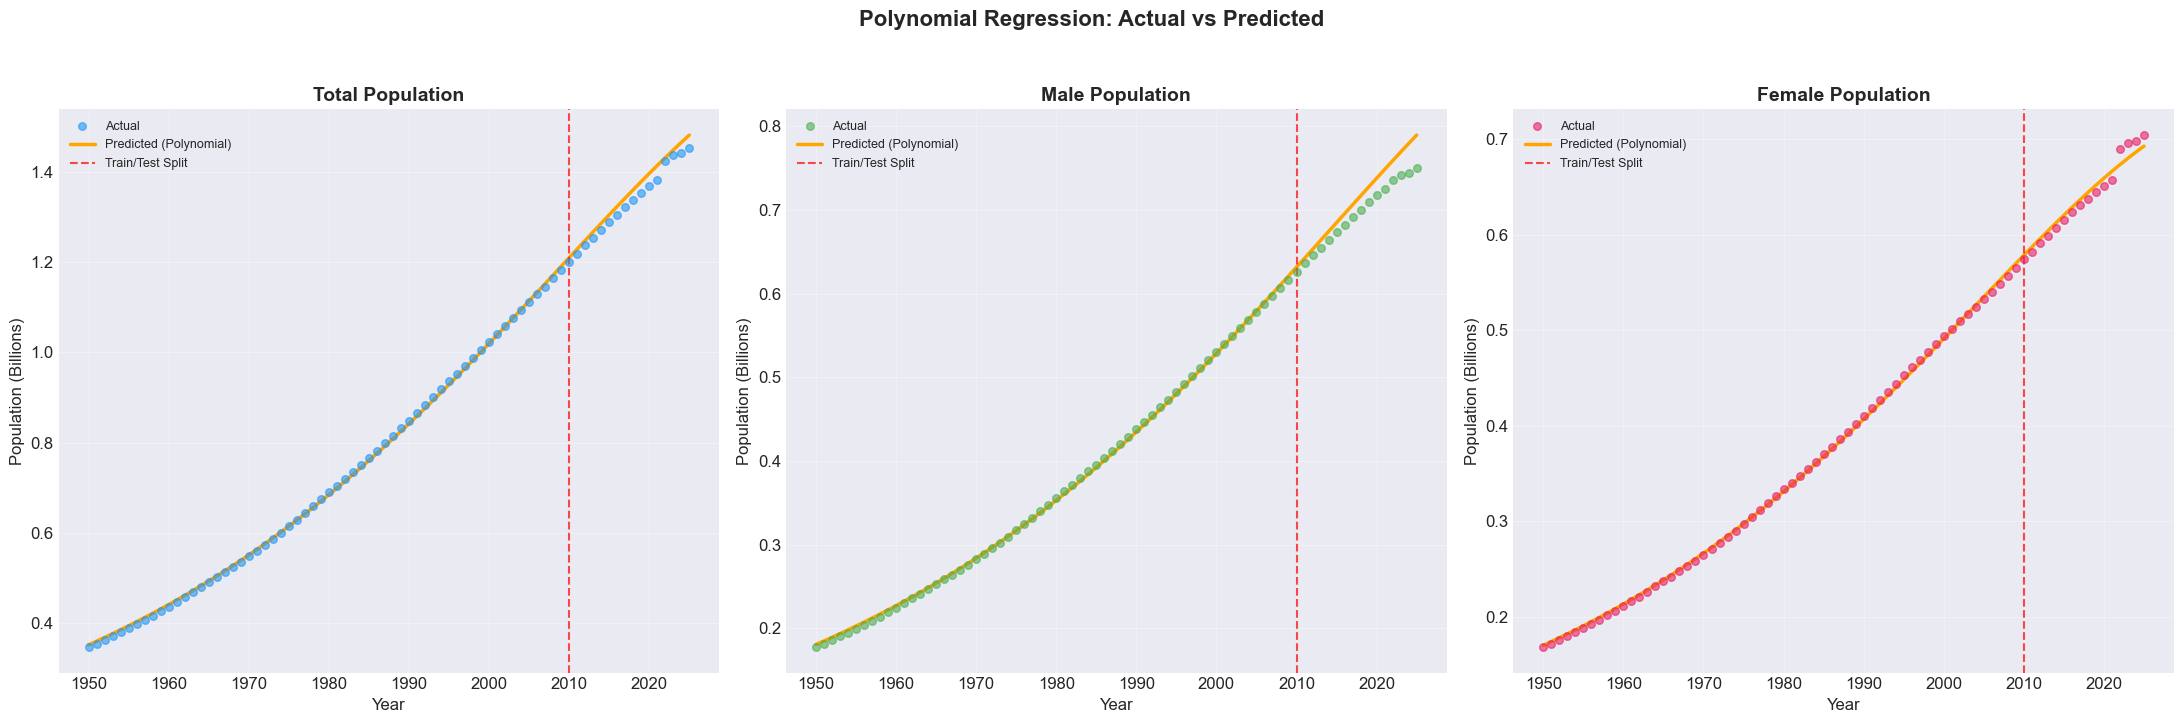

In [64]:
# Predict on full dataset for visualization
all_pred_total = model_total.predict(X)
all_pred_male = model_male.predict(X)
all_pred_female = model_total.predict(X) - model_male.predict(X)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
years = df_model['Year'].values
train_years = years[:split_idx]
test_years = years[split_idx:]

targets = [
    ('Total Population', y_total, all_pred_total, '#2196F3'),
    ('Male Population', y_male, all_pred_male, '#4CAF50'),
    ('Female Population', y_female, all_pred_female, '#E91E63')
]

for idx, (name, actual, predicted, color) in enumerate(targets):
    ax = axes[idx]
    ax.scatter(years, actual / 1e9, color=color, alpha=0.6, s=30, label='Actual', zorder=3)
    ax.plot(years, predicted / 1e9, color='orange', linewidth=2.5, label='Predicted (Polynomial)', zorder=2)
    ax.axvline(x=years[split_idx], color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Population (Billions)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial Regression: Actual vs Predicted', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

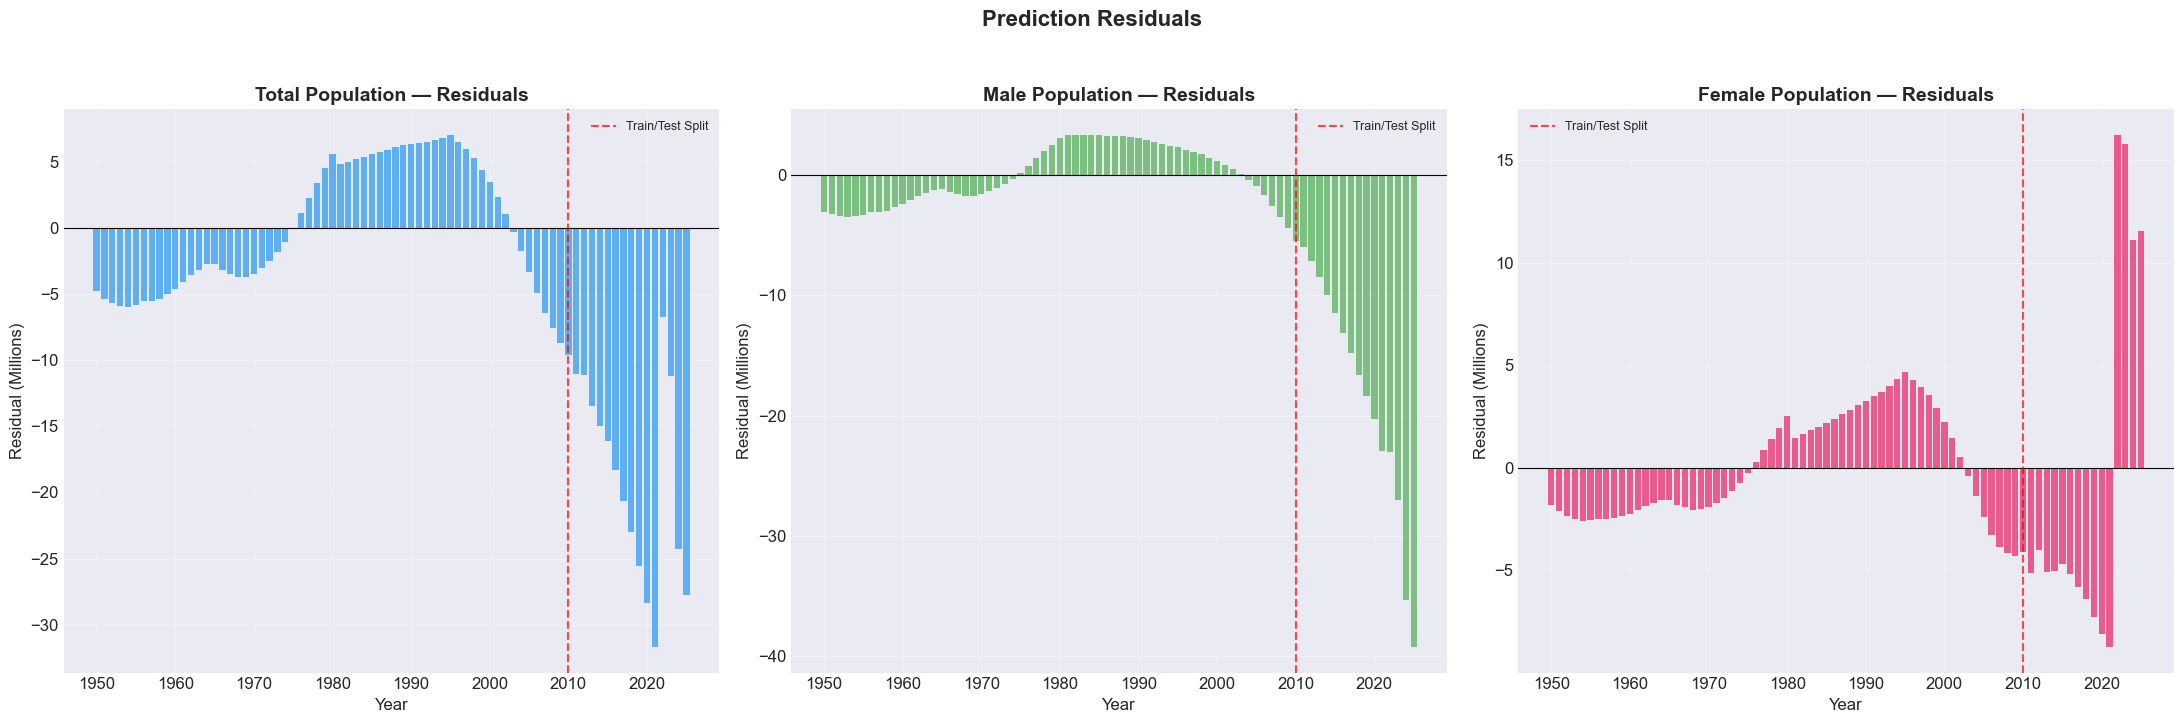

In [65]:
# Residual Analysis
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for idx, (name, actual, predicted, color) in enumerate(targets):
    ax = axes[idx]
    residuals = (actual - predicted) / 1e6
    ax.bar(years, residuals, color=color, alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.axvline(x=years[split_idx], color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
    ax.set_title(f'{name} — Residuals', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Residual (Millions)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Prediction Residuals', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 10. Polynomial Coefficients Analysis

In [66]:
# Show polynomial feature names and coefficients
poly_features = model_total.named_steps['poly']
feature_names = poly_features.get_feature_names_out(['Years_Since_1950'])

for name, model in [('Total Population', model_total), ('Male Population', model_male), ('Female Population', model_female)]:
    ridge = model.named_steps['ridge']
    scaler = model.named_steps['scaler']
    
    print(f'\n📊 {name} — Ridge Regression')
    print(f'  Intercept: {ridge.intercept_:,.0f}')
    print(f'  Polynomial Features & Coefficients (scaled):')
    for fname, coef in zip(feature_names, ridge.coef_):
        print(f'    {fname:<30}: {coef:>20,.2f}')
    print()

NameError: name 'model_female' is not defined

## 11. Future Predictions (2026 - 2050)

In [ ]:
# Generate future years
future_years = np.arange(2026, 2051)
future_X = (future_years - 1950).reshape(-1, 1)

# Predict Total and Male
future_total = model_total.predict(future_X)
future_male = model_male.predict(future_X)

# Derive Female as Total - Male (guarantees consistency!)
future_female = future_total - future_male

# Create predictions DataFrame
predictions_df = pd.DataFrame({
    'Year': future_years,
    'Predicted Total Population': future_total.astype(int),
    'Predicted Male Population': future_male.astype(int),
    'Predicted Female Population': future_female.astype(int)
})

# Verify consistency
predictions_df['Male + Female'] = predictions_df['Predicted Male Population'] + predictions_df['Predicted Female Population']
predictions_df['Consistent'] = predictions_df['Male + Female'] == predictions_df['Predicted Total Population']

print('📊 Future Population Predictions (2026-2050)')
print(f'✅ All predictions consistent (Male + Female = Total): {predictions_df["Consistent"].all()}\n')
predictions_df[['Year', 'Predicted Total Population', 'Predicted Male Population', 'Predicted Female Population']]

## 12. Visualization: Historical + Future Predictions

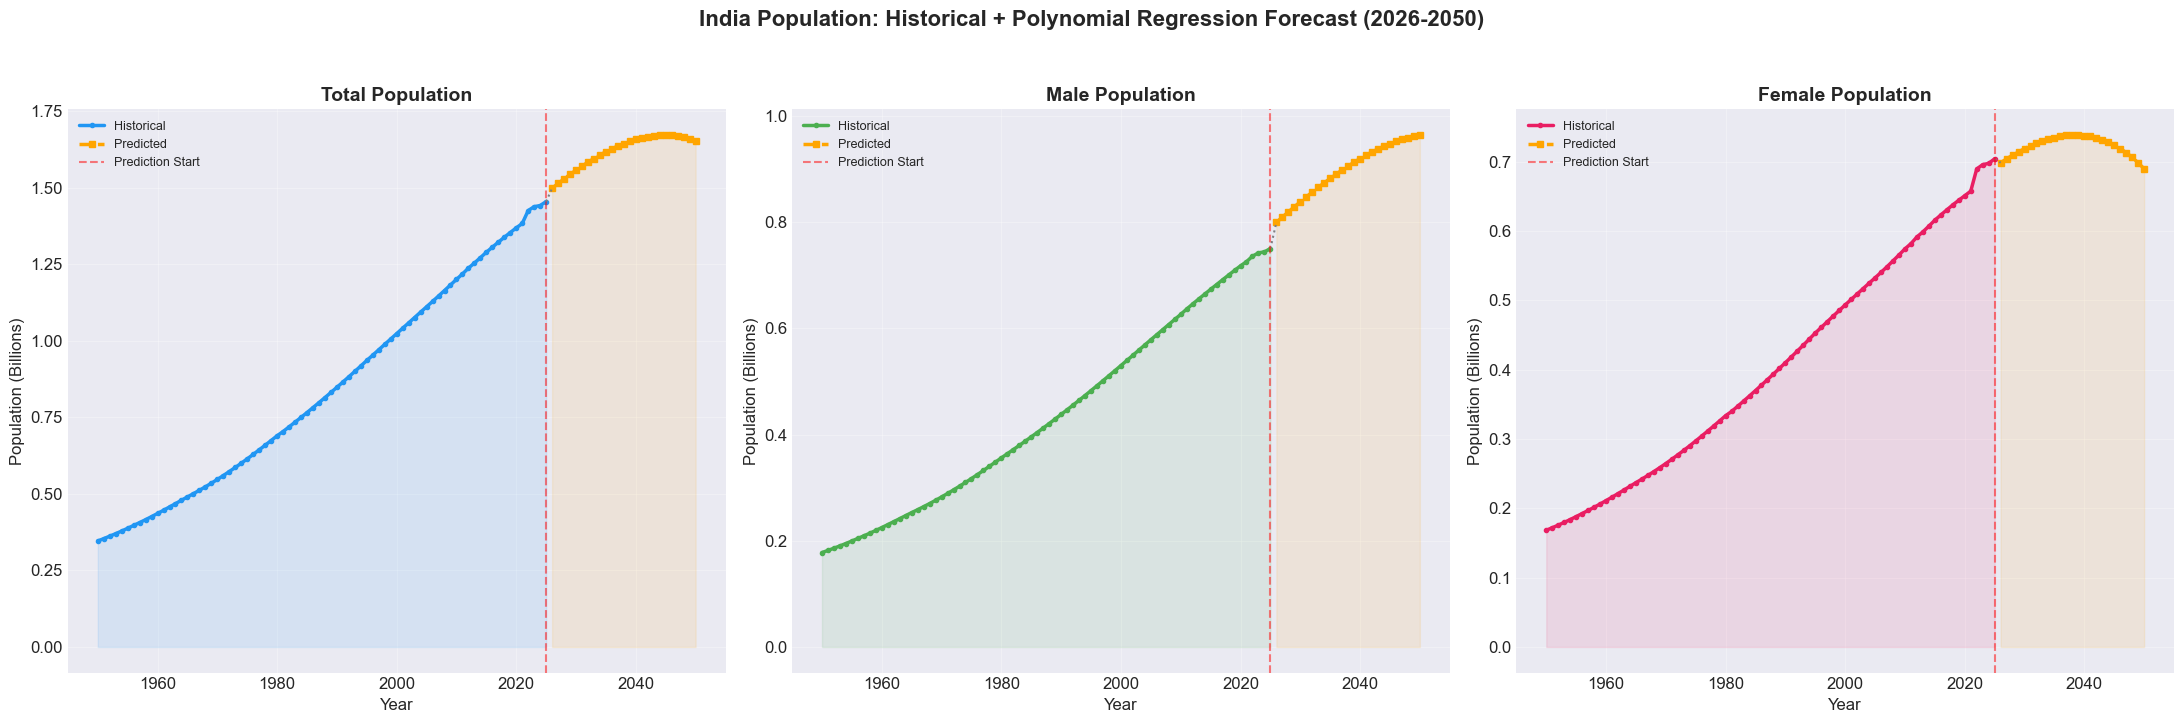

In [ ]:
# Plot historical data + future predictions
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

plot_data = [
    ('Total Population', y_total, future_total, '#2196F3'),
    ('Male Population', y_male, future_male, '#4CAF50'),
    ('Female Population', y_female, future_female, '#E91E63')
]

for idx, (name, hist_y, fut_y, color) in enumerate(plot_data):
    ax = axes[idx]
    
    # Historical
    ax.plot(years, hist_y / 1e9, color=color, linewidth=2.5, marker='o', markersize=3, label='Historical')
    ax.fill_between(years, hist_y / 1e9, alpha=0.1, color=color)
    
    # Future predictions
    ax.plot(future_years, fut_y / 1e9, color='orange', linewidth=2.5, marker='s', markersize=4, 
            linestyle='--', label='Predicted')
    ax.fill_between(future_years, fut_y / 1e9, alpha=0.1, color='orange')
    
    # Transition line
    ax.plot([years[-1], future_years[0]], [hist_y[-1] / 1e9, fut_y[0] / 1e9], 
            color='gray', linewidth=1.5, linestyle=':')
    
    ax.axvline(x=2025, color='red', linestyle='--', alpha=0.5, label='Prediction Start')
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Population (Billions)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('India Population: Historical + Polynomial Regression Forecast (2026-2050)', 
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


📈 Predicted Year-over-Year Growth Rate (Total Population)



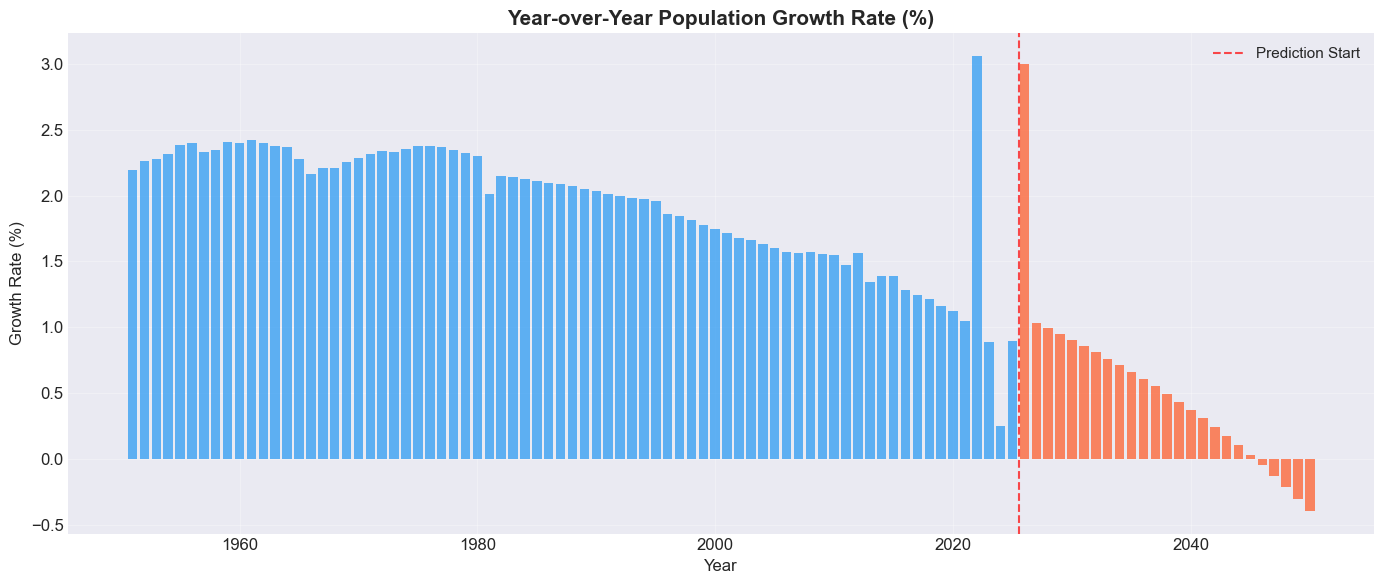

In [ ]:
# Year-over-Year Growth Rate Analysis
print('\n📈 Predicted Year-over-Year Growth Rate (Total Population)\n')

# Historical growth rates
hist_growth = []
for i in range(1, len(y_total)):
    rate = ((y_total[i] - y_total[i-1]) / y_total[i-1]) * 100
    hist_growth.append(rate)

# Future growth rates
all_pop = np.concatenate([y_total, future_total])
future_growth = []
for i in range(len(y_total), len(all_pop)):
    rate = ((all_pop[i] - all_pop[i-1]) / all_pop[i-1]) * 100
    future_growth.append(rate)

fig, ax = plt.subplots(figsize=(14, 6))
all_years_growth = list(range(1951, 2026)) + list(range(2026, 2051))
all_growth = hist_growth + future_growth

colors = ['#2196F3'] * len(hist_growth) + ['#FF5722'] * len(future_growth)
ax.bar(all_years_growth, all_growth, color=colors, alpha=0.7)
ax.axvline(x=2025.5, color='red', linestyle='--', alpha=0.7, label='Prediction Start')
ax.set_title('Year-over-Year Population Growth Rate (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate (%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Save Predictions to CSV

In [ ]:
# Save future predictions to CSV
predictions_df.to_csv('india_population_predictions_2026_2050.csv', index=False)
print('✅ Predictions saved to: india_population_predictions_2026_2050.csv')

# Save complete dataset (historical + predictions)
historical_df = df[['Year', 'Total Population', 'Male Population', 'Female Population']].copy()
historical_df.columns = ['Year', 'Predicted Total Population', 'Predicted Male Population', 'Predicted Female Population']
historical_df['Type'] = 'Historical'

future_df = predictions_df.copy()
future_df['Type'] = 'Predicted'

complete_df = pd.concat([historical_df, future_df], ignore_index=True)
complete_df.to_csv('india_population_complete_1950_2050.csv', index=False)
print('✅ Complete dataset saved to: india_population_complete_1950_2050.csv')
print(f'\n📊 Complete Dataset: {complete_df.shape[0]} rows ({historical_df.shape[0]} historical + {future_df.shape[0]} predicted)')

✅ Predictions saved to: india_population_predictions_2026_2050.csv
✅ Complete dataset saved to: india_population_complete_1950_2050.csv

📊 Complete Dataset: 101 rows (76 historical + 25 predicted)


## 14. Model Summary

---

### ✅ Key Results

| Aspect | Details |
|--------|--------|
| **Algorithm** | Polynomial Regression (Ridge) |
| **Training Data** | India Population (1950–2025) |
| **Targets** | Total, Male, Female Population |
| **Feature** | Years_Since_1950 → Polynomial Features |
| **Validation** | TimeSeriesSplit (5-fold) |
| **Regularization** | Ridge (L2) |
| **Future Predictions** | 2026 to 2050 |

### 📌 Why Polynomial Regression?
- India's population follows a **smooth, monotonic trend** — ideal for polynomial fitting
- **Can extrapolate** beyond the training range (unlike Random Forest)
- Works well with **small datasets** (76 data points)
- **TimeSeriesSplit** cross-validation preserves temporal ordering
- Ridge regularization prevents overfitting on higher-degree polynomials

### 📌 Notes
- Data sourced from **UN World Population Prospects (2024 Revision)**
- Polynomial regression captures India's demographic transition (slowing growth rate)
- For very long-range predictions, consider ensemble or domain-specific demographic models